In [1]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd
from scipy import stats
from scipy.optimize import minimize

np.random.seed(42)

In [2]:
tickers = ["AAPL",'MSFT','GOOGL','JPM','GS']
data = yf.download(tickers, start = "2020-01-01", end="2026-01-01")
prices=data["Close"]
log_returns= np.log(prices/prices.shift(1)).dropna()

mean_returns= log_returns.mean() *252
cov_matrix = log_returns.cov() * 252
risk_free_rate = 0.047
n_assets=len(tickers)

def portfolio_volatility(weights,cov_matrix):
    return np.sqrt(np.dot(weights.T,np.dot(cov_matrix,weights)))

def negative_sharpe(weights, mean_returns,cov_matrix,rf):
    ret=np.dot(weights, mean_returns)
    vol=portfolio_volatility(weights,cov_matrix)
    return -(ret-rf)/vol

constraints = {'type':'eq', 'fun': lambda w: np.sum(w)-1}
bounds = tuple((0,1) for _ in range(n_assets))
w0 = np.array([1/n_assets]*n_assets)

result= minimize(negative_sharpe,w0,args=(mean_returns,cov_matrix,risk_free_rate),method="SLSQP",bounds=bounds,constraints=constraints)

optimal_weights=result.x
optimal_return= np.dot(optimal_weights, mean_returns)
optimal_vol= portfolio_volatility(optimal_weights,cov_matrix)

print("Optimal portfolio weights:")
for t, w in zip(tickers,optimal_weights):
    print(f" {t}: {w:.2%}")
print(f"\nExpected annual return: {optimal_return:.2%}")
print(f"Annual volatility: {optimal_vol:.2%}")
print(f"Sharpe ratio: {(optimal_return - risk_free_rate)/optimal_vol:.4f}")

[*********************100%***********************]  5 of 5 completed

Optimal portfolio weights:
 AAPL: 14.25%
 MSFT: 45.11%
 GOOGL: 40.65%
 JPM: 0.00%
 GS: 0.00%

Expected annual return: 24.63%
Annual volatility: 27.06%
Sharpe ratio: 0.7366


In [3]:
#Monte Carlo Forward Simulation:

n_simulations= 1000
n_days=252
initial_portfolio_value=10000 # invest starting with $10000

#convert annualized back to daily
daily_mean = np.dot(optimal_weights,log_returns.mean())
daily_cov= log_returns.cov()

simulation_results = np.zeros((n_days,n_simulations))

for sim in range(n_simulations):
    daily_returns = np.random.multivariate_normal(mean=log_returns.mean(), cov=daily_cov,size=n_days) # draws correlated rand returns for the
    #assets simultaneously. More realistic than simulation each asset independently

    portfolio_daily_returns=daily_returns @ optimal_weights # @ is np.dot()

    # portfolio value path by compounding returns
    price_path= initial_portfolio_value * np.exp(np.cumsum(portfolio_daily_returns))
    simulation_results[:,sim]=price_path

In [4]:
# print("Shape of simulation_results:", simulation_results.shape)
# print("\nFirst simulation, first 5 days:")
# print(simulation_results[:5, 0])
# print("\nMin value across all simulations:", simulation_results.min())
# print("Max value across all simulations:", simulation_results.max())

In [5]:
# print("Optimal weights:", optimal_weights)
# print("Sum of weights:", optimal_weights.sum())
# print("Initial value:", initial_portfolio_value)
# print("Daily mean returns:", log_returns.mean().values)

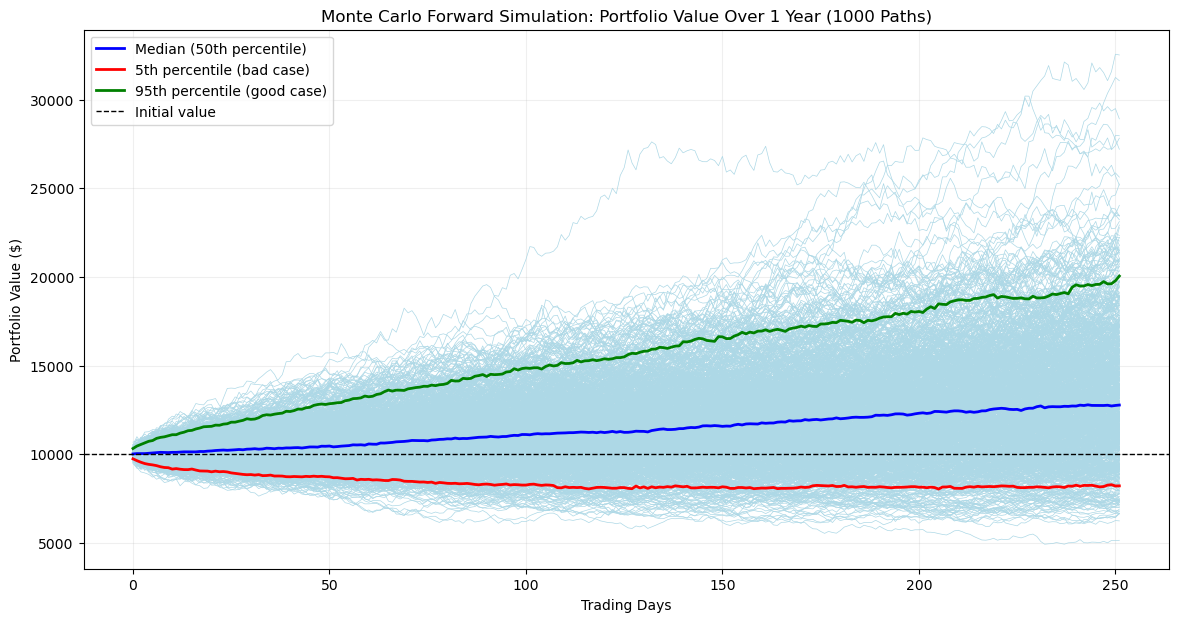

In [6]:
#Plot

plt.figure(figsize=(14,7))

plt.plot(simulation_results,color="lightblue",alpha=1,linewidth=0.5)

plt.plot(np.percentile(simulation_results,50,axis=1),color="blue",linewidth=2,label='Median (50th percentile)')
plt.plot(np.percentile(simulation_results,5,axis=1),color="red",linewidth=2,label="5th percentile (bad case)")
plt.plot(np.percentile(simulation_results,95,axis=1),color="green",linewidth=2,label="95th percentile (good case)")

plt.axhline(y=initial_portfolio_value,color='black',linestyle="--",linewidth=1,label="Initial value")

plt.title("Monte Carlo Forward Simulation: Portfolio Value Over 1 Year (1000 Paths)")
plt.xlabel("Trading Days")
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True,alpha=0.2)
plt.show()

In [7]:
final_values = simulation_results[-1, :]  # last day of all simulations

print(f"Starting portfolio value:        ${initial_portfolio_value:,.0f}")
print(f"Median final value:              ${np.median(final_values):,.0f}")
print(f"Mean final value:                ${np.mean(final_values):,.0f}")
print(f"5th percentile (bad scenario):   ${np.percentile(final_values, 5):,.0f}")
print(f"95th percentile (good scenario): ${np.percentile(final_values, 95):,.0f}")
print(f"Probability of loss:             {(final_values < initial_portfolio_value).mean():.2%}")

Starting portfolio value:        $10,000
Median final value:              $12,769
Mean final value:                $13,311
5th percentile (bad scenario):   $8,209
95th percentile (good scenario): $20,046
Probability of loss:             19.10%


In [8]:
# VaR to calculate the potential loss of portfolio value with confidence level(z) over a given period

#1. Historical VaR
hist_portfolio_returns = log_returns @ optimal_weights

confidence=0.95
var_hist = np.percentile(hist_portfolio_returns, (1-confidence)*100)

print(f"Historical 1-day 95% VaR: {var_hist:.4f}")
print(f"Historical 1-day 95% VaR (dollar, $10k portfolio): ${var_hist*initial_portfolio_value:,.2f}")

Historical 1-day 95% VaR: -0.0245
Historical 1-day 95% VaR (dollar, $10k portfolio): $-244.79


In [34]:
# VaR = -0.0245 means that on the worst 5% of trading days historically, the portfolio would lose 2.45%

In [35]:
#2. Parametric VaR = mean-SD*z

mu=hist_portfolio_returns.mean()
sigma=hist_portfolio_returns.std()

var_parametric = stats.norm.ppf(1-confidence,mu,sigma) #inverse of normal CDF

print(f"Parametric 1-day 95% VaR: {var_parametric:.4f}")
print(f"Parametric 1-day 95% VaR (dollar): ${var_parametric * initial_portfolio_value:,.2f}")

# Parametric assumes normal dist and underestimates tail risk

Parametric 1-day 95% VaR: -0.0271
Parametric 1-day 95% VaR (dollar): $-270.58


In [43]:

# print(f"Daily sigma:{portfolio_returns.std()}")
# print(f"Worst single day:{portfolio_returns.min()}")
# print(f"Kurtosis:{portfolio_returns.kurtosis()}")
# print(f"Skewness:{portfolio_returns.skew()}")

# # how many days were more extreme than your parametric VaR
# extreme_days = (portfolio_returns < var_parametric).sum()
# print(f"{extreme_days}/{len(portfolio_returns)}")

In [13]:
#3. Monte Carlo Sim VaR

sim_day1_returns=(simulation_results[0,:]-initial_portfolio_value)/initial_portfolio_value

var_simulation = np.percentile(sim_day1_returns,(1-confidence)*100)
print(f"Simulation 1-day 95% VaR (return): {var_simulation:.4f}")
print(f"Simulation 1-day 95% VaR (dollars): ${var_simulation*initial_portfolio_value:,.2f}")

Simulation 1-day 95% VaR (return): -0.0265
Simulation 1-day 95% VaR (dollars): $-265.43


In [15]:
# CVaR: average returns that could be expected beyond VaR thresholds. Thus CVaR always >= VaR


losses_beyond_var= hist_portfolio_returns[hist_portfolio_returns <= var_hist]
cvar_hist= losses_beyond_var.mean()

print(f"Historical 95% VaR: {var_hist:.4f} (${var_hist*initial_portfolio_value})")
print(f"Historical 95% VaR: {cvar_hist:.4f} (${cvar_hist*initial_portfolio_value})")

Historical 95% VaR: -0.0245 ($-244.78616136055064)
Historical 95% VaR: -0.0404 ($-403.576722244384)


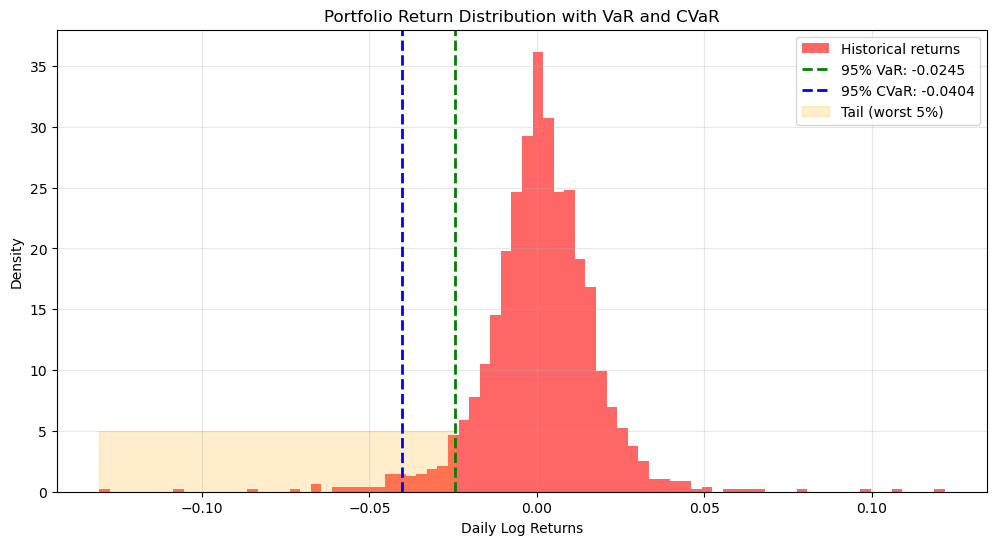

In [23]:
plt.figure(figsize=(12,6))

plt.hist(hist_portfolio_returns,bins=80,density=True,alpha=0.6,color="red",label="Historical returns")
plt.axvline(x=var_hist,color='green',linewidth='2',linestyle="--",label=f"95% VaR: {var_hist:.4f}")
plt.axvline(x=cvar_hist,color='blue',linewidth='2',linestyle="--",label=f"95% CVaR: {cvar_hist:.4f}")

#shade tail beyond VaR
# x_tail= np.linspace(hist_portfolio_returns.min(),var_hist,100)
plt.fill_betweenx([0,5],hist_portfolio_returns.min(),var_hist,alpha=0.2, color='orange',label='Tail (worst 5%)')

plt.title("Portfolio Return Distribution with VaR and CVaR")
plt.xlabel("Daily Log Returns")
plt.ylabel("Density")
plt.legend()
plt.grid(True,alpha=0.3)
plt.show()

In [27]:
#Scale VaR to longer periods of time
#square root of time to convert our risk measure from our initial 1 day period to other time durations:
# so using historical VaR we'd do the following: histroical VaR * √(new time period)

hold_period=[1,5,10,21,63,252]
period_labels=['1 Day', '1 Week', '2 Weeks', '1Month', '1 Year']

print(f"VaR scaled across holding periods at 95% confidence, ${initial_portfolio_value}:")
print(f"{'Period':<12}{'VaR Return': <15} {"VaR Dollar"}")
print("-"*40)

for period, label in zip(hold_period,period_labels):
    scaled_var = var_hist * np.sqrt(period)
    print(f"{label:<12}{scaled_var:<15.4f} ${scaled_var*initial_portfolio_value}")

VaR scaled across holding periods at 95% confidence, $10000:
Period      VaR Return      VaR Dollar
----------------------------------------
1 Day       -0.0245         $-244.78616136055064
1 Week      -0.0547         $-547.3584967534237
2 Weeks     -0.0774         $-774.0818095888415
1Month      -0.1122         $-1121.7511135123978
1 Year      -0.1943         $-1942.9299220504358


In [29]:
 This notebook we stress-test the optimal portfolio obtained from week 5 and simulate 1000 possible futures using Monte Carlo. Each simulated
path uses correlated daily returns from the historical averages and covariance of the 5 assets, then it compounds them forward across
a trading year (252 days) to make a realistic distribution of possible portfolio vales one year from the end date we downloaded our data from.
Using the distribution, I estimated 3 Value at Risk using parametric, historical, and Monte Carlo Simulation methods, and comparing them 
reveals how the assumption of normality underestimates tail risk. Conditional VaR was added to address the weakness of VaR, as VaR only finds
the loss threshold at 5th percentile, CVaR quantifies the average sevirity of the loss beyond that threshold, expanding the picture of
how much can av=ctually be lost. Finally, I used the square root of time rule to scale the single say VaR estimate across holding periods
from 1 day to a full year; this shows that risk accumulates with time in a non-linear way.

IndentationError: unexpected indent (2829241953.py, line 1)